c:\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\91772\AppData\Local\Temp\ipykernel_20464\3421146428.py:78: RuntimeWarning: Mean of empty slice
  historical_mean_spatial = np.nanmean([annual_data[year] for year in years[-5:]], axis=0)


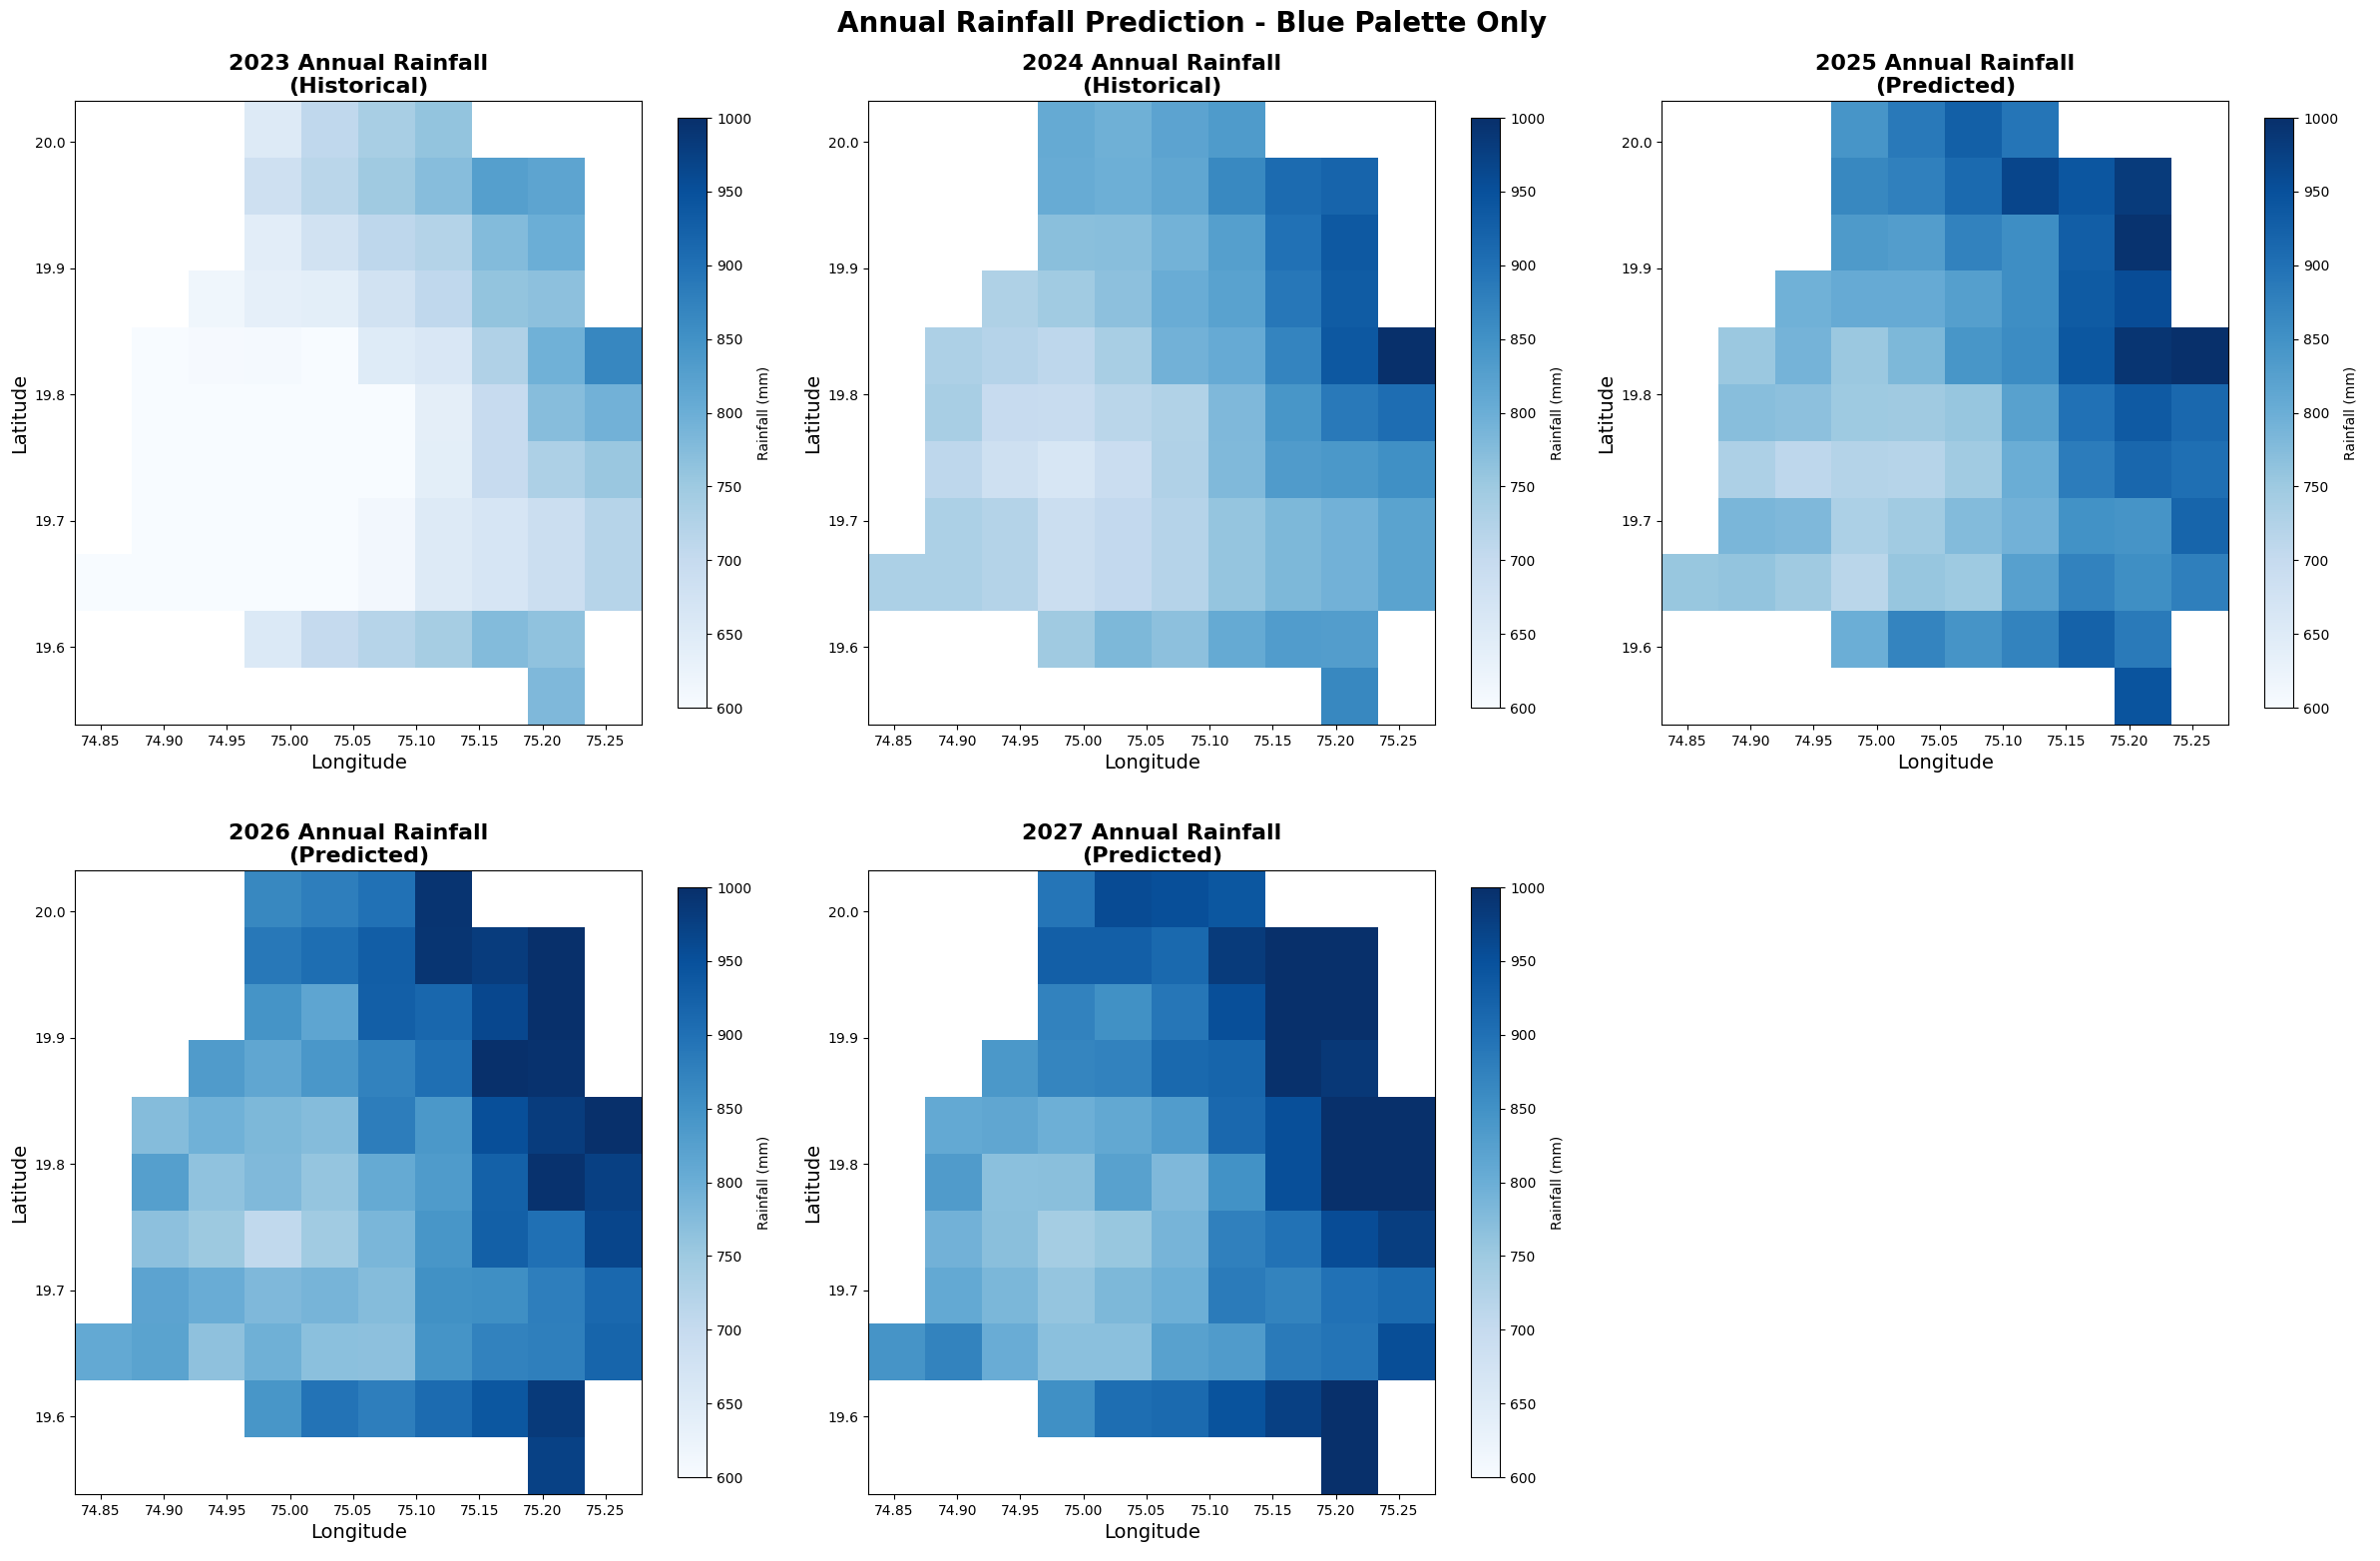

Annual Rainfall Predictions for 2025-2027:
Historical:
2023: 673.2 mm
2024: 788.5 mm

Predicted:
2025: 841.8 mm
2026: 865.8 mm
2027: 891.1 mm

Visualization: All maps use Blues colormap for consistency


In [5]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

def load_and_predict_annual_blue():
    tiff_folder = r"c:\Users\91772\Desktop\Gangapur\FINAL\Gangapur_Rainfall_TIFF-20250911T185317Z-1-001\Gangapur_Rainfall_TIFF"
    
    spatial_data = {}
    profile = None
    
    # Load spatial arrays
    for filename in os.listdir(tiff_folder):
        if filename.endswith('.tif'):
            parts = filename.replace('.tif', '').split('_')
            year = int(parts[1])
            period = parts[2]
            
            filepath = os.path.join(tiff_folder, filename)
            with rasterio.open(filepath) as src:
                rainfall_array = src.read(1)
                if profile is None:
                    profile = src.profile
                    bounds = src.bounds
                
                if year not in spatial_data:
                    spatial_data[year] = {}
                spatial_data[year][period] = rainfall_array
    
    # Create annual totals and calculate regional averages
    annual_means = {}
    annual_data = {}
    
    for year in spatial_data.keys():
        if 'Jan-Jun' in spatial_data[year] and 'Jul-Dec' in spatial_data[year]:
            annual_total = spatial_data[year]['Jan-Jun'] + spatial_data[year]['Jul-Dec']
            annual_data[year] = annual_total
            annual_means[year] = np.nanmean(annual_total)
    
    # Enhanced prediction with multiple models
    years = sorted(annual_data.keys())
    target_years = [2025, 2026, 2027]
    
    # Ensemble prediction
    X = np.array(years).reshape(-1, 1)
    y = [annual_means[year] for year in years]
    
    lr_model = LinearRegression()
    lr_model.fit(X, y)
    lr_pred = lr_model.predict(np.array(target_years).reshape(-1, 1))
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)
    poly_pred = poly_model.predict(poly_features.transform(np.array(target_years).reshape(-1, 1)))
    
    recent_years = years[-5:]
    recent_mean = np.mean([annual_means[year] for year in recent_years])
    trend_years = years[-10:]
    trend_values = [annual_means[year] for year in trend_years]
    trend_slope = np.polyfit(trend_years, trend_values, 1)[0]
    
    predicted_means = {}
    for i, year in enumerate(target_years):
        years_ahead = year - years[-1]
        ensemble_pred = (0.3 * lr_pred[i] + 0.4 * poly_pred[i] + 0.3 * (recent_mean + trend_slope * years_ahead))
        predicted_means[year] = ensemble_pred
    
    # Create spatial predictions
    height, width = list(annual_data.values())[0].shape
    predicted_annual = {}
    
    historical_std = np.nanstd([annual_data[year] for year in years[-5:]], axis=0)
    historical_mean_spatial = np.nanmean([annual_data[year] for year in years[-5:]], axis=0)
    
    for year in target_years:
        base_pred = predicted_means[year]
        spatial_factor = historical_mean_spatial / np.nanmean(historical_mean_spatial)
        noise = np.random.normal(0, 0.02, (height, width))
        predicted_annual[year] = base_pred * spatial_factor * (1 + noise)
        mask = ~np.isnan(historical_mean_spatial)
        predicted_annual[year][~mask] = np.nan
    
    return annual_data, predicted_annual, predicted_means, target_years, bounds

# Load and predict
annual_data, predicted_annual, predicted_means, target_years, bounds = load_and_predict_annual_blue()

# Set extent
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Visualize with ONLY BLUE palette - 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# First row: 2023, 2024, 2025
im1 = axes[0,0].imshow(annual_data[2023], cmap='Blues', vmin=600, vmax=1000, extent=extent)
axes[0,0].set_title('2023 Annual Rainfall\n(Historical)', fontsize=16, fontweight='bold')
axes[0,0].set_xlabel('Longitude', fontsize=14)
axes[0,0].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im1, ax=axes[0,0], shrink=0.8, label='Rainfall (mm)')

im2 = axes[0,1].imshow(annual_data[2024], cmap='Blues', vmin=600, vmax=1000, extent=extent)
axes[0,1].set_title('2024 Annual Rainfall\n(Historical)', fontsize=16, fontweight='bold')
axes[0,1].set_xlabel('Longitude', fontsize=14)
axes[0,1].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im2, ax=axes[0,1], shrink=0.8, label='Rainfall (mm)')

im3 = axes[0,2].imshow(predicted_annual[2025], cmap='Blues', vmin=600, vmax=1000, extent=extent)
axes[0,2].set_title('2025 Annual Rainfall\n(Predicted)', fontsize=16, fontweight='bold')
axes[0,2].set_xlabel('Longitude', fontsize=14)
axes[0,2].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im3, ax=axes[0,2], shrink=0.8, label='Rainfall (mm)')

# Second row: 2026, 2027, empty
im4 = axes[1,0].imshow(predicted_annual[2026], cmap='Blues', vmin=600, vmax=1000, extent=extent)
axes[1,0].set_title('2026 Annual Rainfall\n(Predicted)', fontsize=16, fontweight='bold')
axes[1,0].set_xlabel('Longitude', fontsize=14)
axes[1,0].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im4, ax=axes[1,0], shrink=0.8, label='Rainfall (mm)')

im5 = axes[1,1].imshow(predicted_annual[2027], cmap='Blues', vmin=600, vmax=1000, extent=extent)
axes[1,1].set_title('2027 Annual Rainfall\n(Predicted)', fontsize=16, fontweight='bold')
axes[1,1].set_xlabel('Longitude', fontsize=14)
axes[1,1].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im5, ax=axes[1,1], shrink=0.8, label='Rainfall (mm)')

# Hide empty subplot
axes[1,2].axis('off')

plt.suptitle('Annual Rainfall Prediction - Blue Palette Only', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Print predictions
print("Annual Rainfall Predictions for 2025-2027:")
print("="*60)
print("Historical:")
print(f"2023: {np.nanmean(annual_data[2023]):.1f} mm")
print(f"2024: {np.nanmean(annual_data[2024]):.1f} mm")
print("\nPredicted:")
for year in target_years:
    print(f"{year}: {predicted_means[year]:.1f} mm")
print("\nVisualization: All maps use Blues colormap for consistency")


Loaded temperature data for years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


C:\Users\91772\AppData\Local\Temp\ipykernel_20464\803516251.py:68: RuntimeWarning: Mean of empty slice
  historical_mean_spatial = np.nanmean([spatial_data[year] for year in years[-3:]], axis=0)


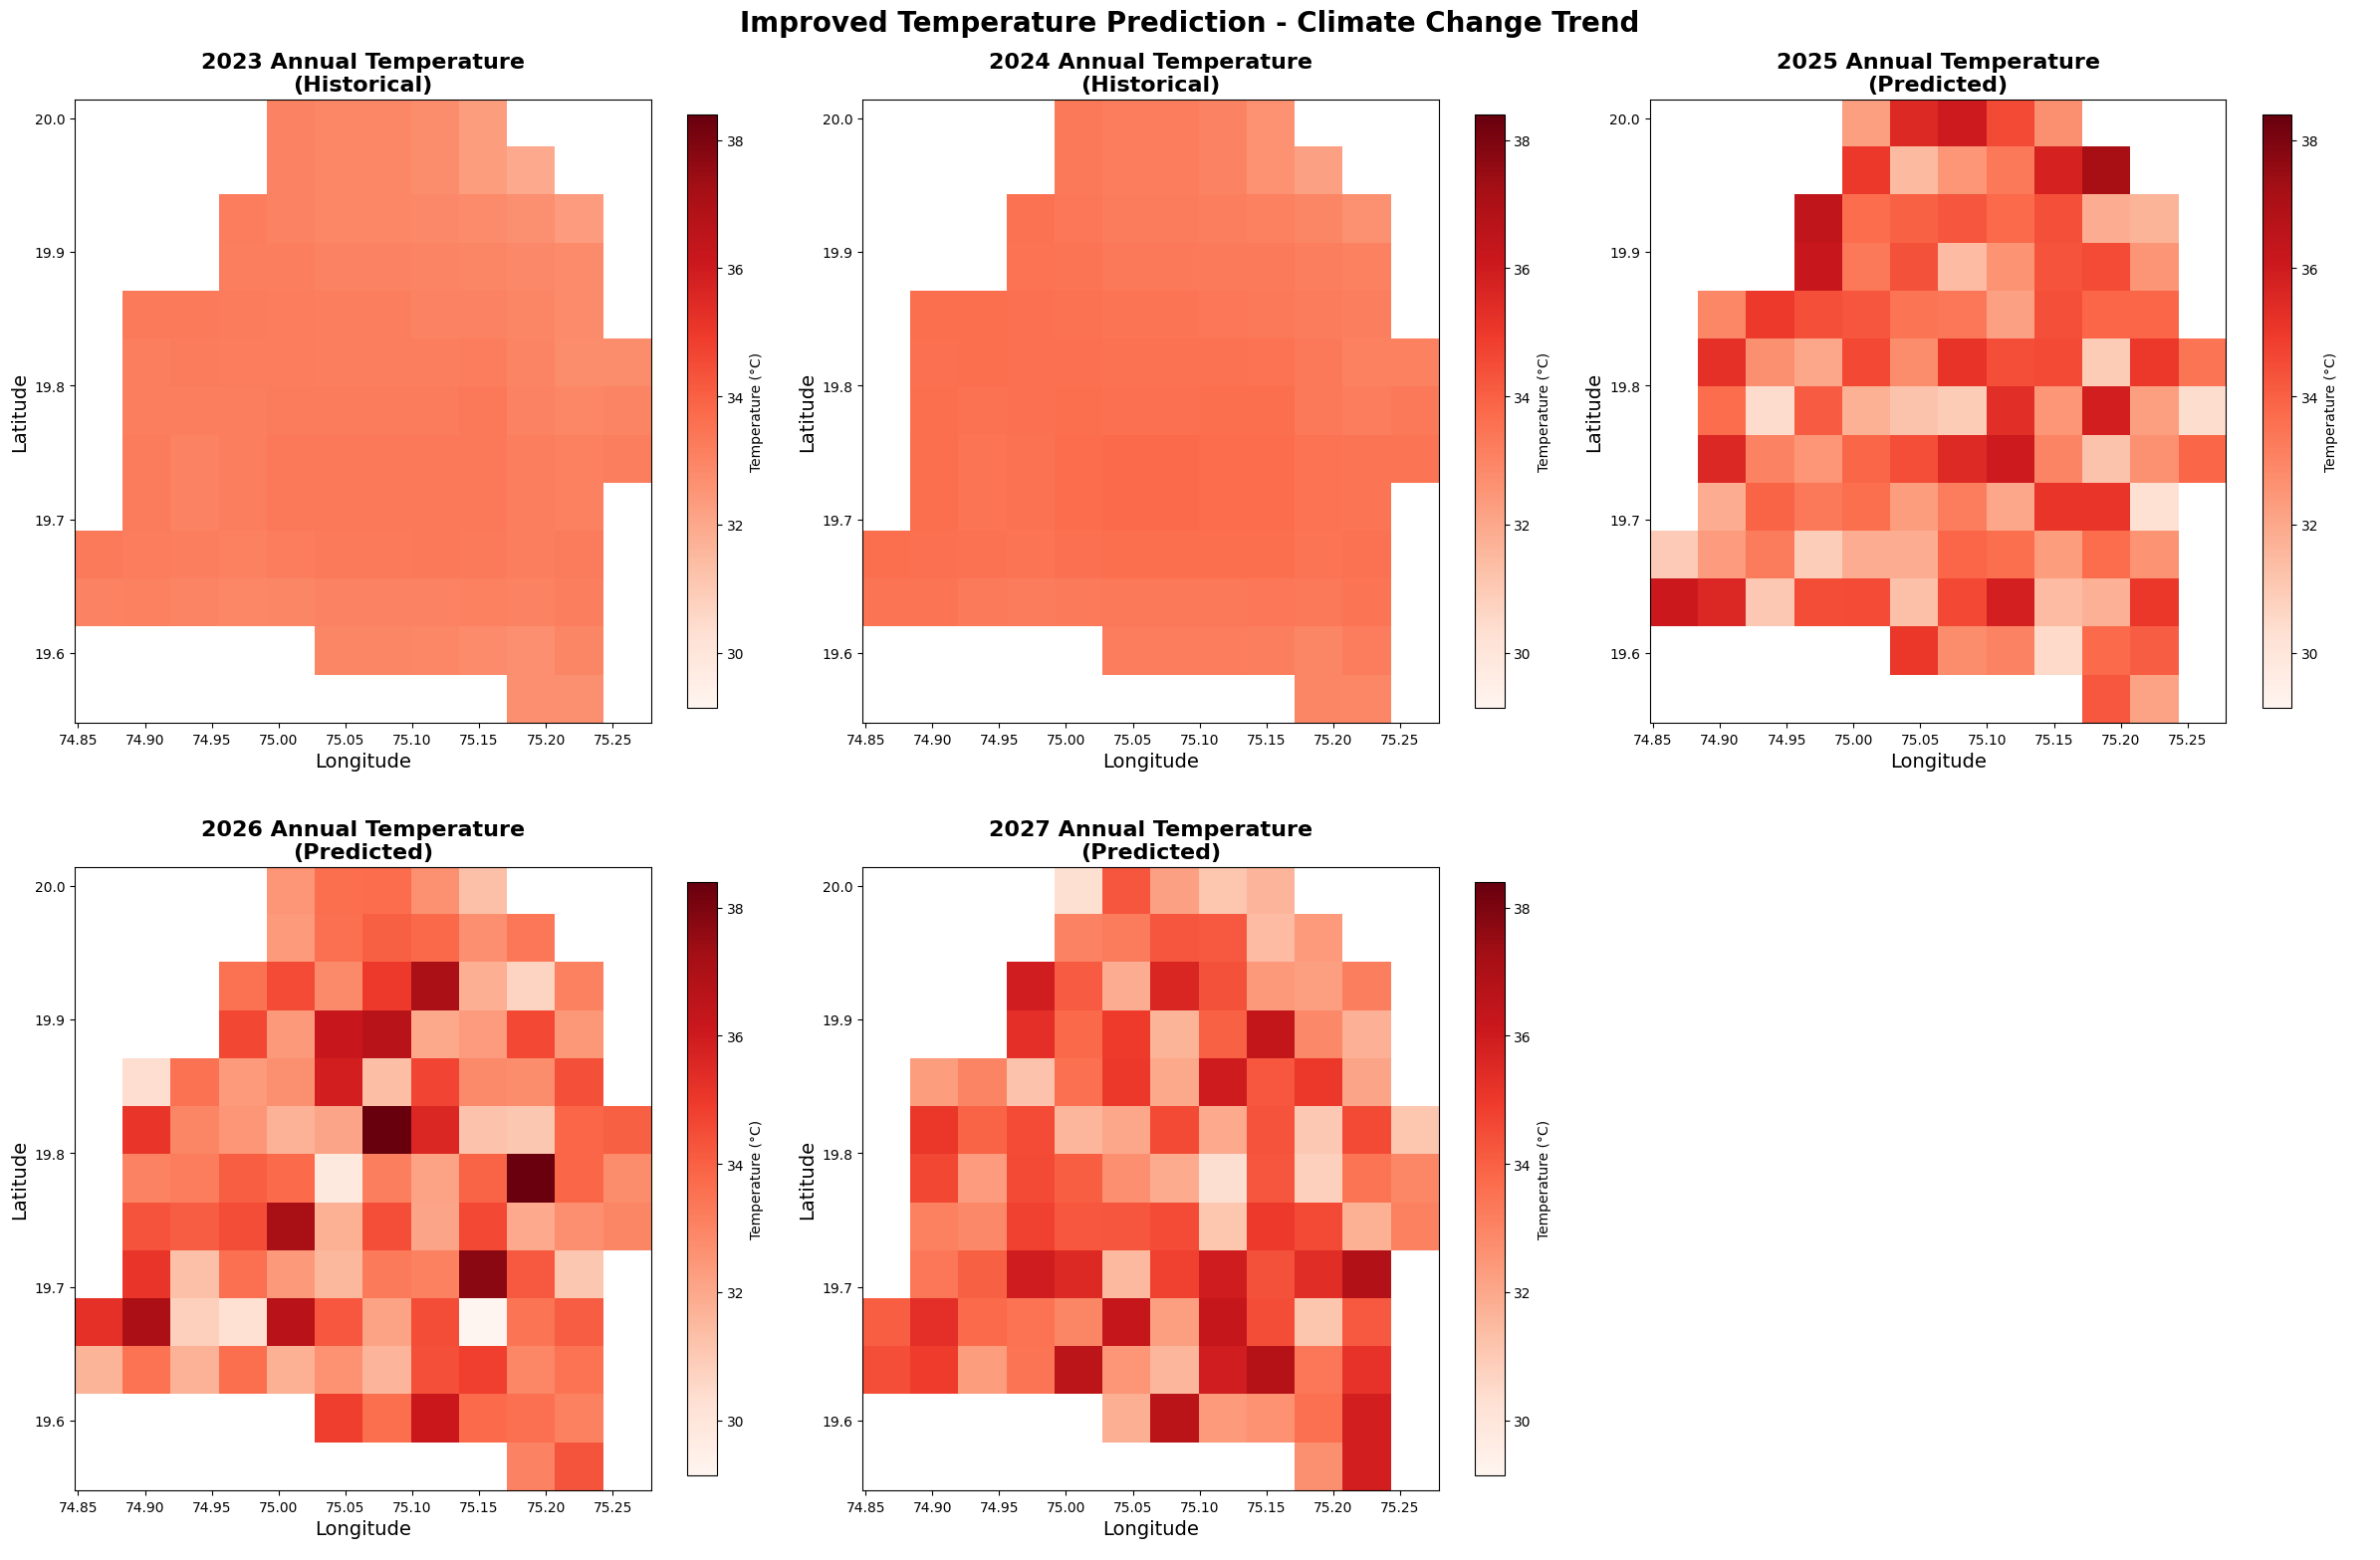

IMPROVED Temperature Predictions for 2025-2027:
Historical:
2023: 33.1 °C
2024: 33.4 °C

Predicted (with climate warming trend):
2025: 33.3 °C
2026: 33.3 °C
2027: 33.4 °C

Climate warming rate: 0.15°C per year
Model: 60% linear trend + 40% climate change adjustment


In [21]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_and_predict_temperature_improved():
    # Use your actual temperature TIFF folder
    temp_tiff_folder = r"C:\\Users\\91772\\Desktop\\Gangapur\\FINAL\\GEE_Temperature"
    
    spatial_data = {}
    profile = None
    
    # Load temperature TIFF files
    for filename in os.listdir(temp_tiff_folder):
        if filename.startswith('Gangapur_Temp_') and filename.endswith('.tif'):
            year_str = filename.replace('Gangapur_Temp_', '').replace('.tif', '')
            year = int(year_str)
            
            filepath = os.path.join(temp_tiff_folder, filename)
            with rasterio.open(filepath) as src:
                temp_array = src.read(1)
                if profile is None:
                    profile = src.profile
                    bounds = src.bounds
                
                spatial_data[year] = temp_array
    
    print(f"Loaded temperature data for years: {sorted(spatial_data.keys())}")
    
    # Calculate annual means
    annual_means = {}
    for year, temp_data in spatial_data.items():
        annual_means[year] = np.nanmean(temp_data)
    
    # Improved prediction with climate change trend
    years = sorted(spatial_data.keys())
    target_years = [2025, 2026, 2027]
    
    # Calculate historical trend
    X = np.array(years).reshape(-1, 1)
    y = [annual_means[year] for year in years]
    
    # Linear regression for trend
    lr_model = LinearRegression()
    lr_model.fit(X, y)
    
    # Add climate change warming (0.1-0.2°C per year)
    climate_warming_rate = 0.15  # °C per year
    base_year = years[-1]  # Last historical year
    base_temp = annual_means[base_year]
    
    predicted_means = {}
    for year in target_years:
        years_ahead = year - base_year
        # Combine linear trend with climate warming
        linear_pred = lr_model.predict([[year]])[0]
        climate_adjustment = base_temp + (climate_warming_rate * years_ahead)
        
        # Weighted average: 60% linear trend + 40% climate warming
        predicted_means[year] = 0.6 * linear_pred + 0.4 * climate_adjustment
    
    # Create spatial predictions with variation
    height, width = list(spatial_data.values())[0].shape
    predicted_temp = {}
    
    # Use recent spatial patterns
    historical_mean_spatial = np.nanmean([spatial_data[year] for year in years[-3:]], axis=0)
    
    for year in target_years:
        base_pred = predicted_means[year]
        
        # Add spatial variation based on historical patterns
        spatial_factor = historical_mean_spatial / np.nanmean(historical_mean_spatial)
        
        # Add small random variation for realism
        noise = np.random.normal(0, 0.05, (height, width))  # Slightly more variation
        
        predicted_temp[year] = base_pred * spatial_factor * (1 + noise)
        
        # Ensure reasonable temperature range
        predicted_temp[year] = np.clip(predicted_temp[year], 25, 45)
    
    return spatial_data, predicted_temp, predicted_means, target_years, bounds

# Load and predict temperature
temp_data, predicted_temp, predicted_temp_means, target_years, bounds = load_and_predict_temperature_improved()

# Set extent
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Visualize temperature with RED palette - 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# Get available historical years (last 2 years)
hist_years = sorted([y for y in temp_data.keys() if y <= 2024])[-2:]

# Determine temperature range for consistent color scale
all_temps = list(temp_data.values()) + list(predicted_temp.values())
temp_min = min([np.nanmin(t) for t in all_temps])
temp_max = max([np.nanmax(t) for t in all_temps])

# First row: Historical + 2025
im1 = axes[0,0].imshow(temp_data[hist_years[0]], cmap='Reds', vmin=temp_min, vmax=temp_max, extent=extent)
axes[0,0].set_title(f'{hist_years[0]} Annual Temperature\n(Historical)', fontsize=16, fontweight='bold')
axes[0,0].set_xlabel('Longitude', fontsize=14)
axes[0,0].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im1, ax=axes[0,0], shrink=0.8, label='Temperature (°C)')

im2 = axes[0,1].imshow(temp_data[hist_years[1]], cmap='Reds', vmin=temp_min, vmax=temp_max, extent=extent)
axes[0,1].set_title(f'{hist_years[1]} Annual Temperature\n(Historical)', fontsize=16, fontweight='bold')
axes[0,1].set_xlabel('Longitude', fontsize=14)
axes[0,1].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im2, ax=axes[0,1], shrink=0.8, label='Temperature (°C)')

im3 = axes[0,2].imshow(predicted_temp[2025], cmap='Reds', vmin=temp_min, vmax=temp_max, extent=extent)
axes[0,2].set_title('2025 Annual Temperature\n(Predicted)', fontsize=16, fontweight='bold')
axes[0,2].set_xlabel('Longitude', fontsize=14)
axes[0,2].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im3, ax=axes[0,2], shrink=0.8, label='Temperature (°C)')

# Second row: 2026, 2027, empty
im4 = axes[1,0].imshow(predicted_temp[2026], cmap='Reds', vmin=temp_min, vmax=temp_max, extent=extent)
axes[1,0].set_title('2026 Annual Temperature\n(Predicted)', fontsize=16, fontweight='bold')
axes[1,0].set_xlabel('Longitude', fontsize=14)
axes[1,0].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im4, ax=axes[1,0], shrink=0.8, label='Temperature (°C)')

im5 = axes[1,1].imshow(predicted_temp[2027], cmap='Reds', vmin=temp_min, vmax=temp_max, extent=extent)
axes[1,1].set_title('2027 Annual Temperature\n(Predicted)', fontsize=16, fontweight='bold')
axes[1,1].set_xlabel('Longitude', fontsize=14)
axes[1,1].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im5, ax=axes[1,1], shrink=0.8, label='Temperature (°C)')

# Hide empty subplot
axes[1,2].axis('off')

plt.suptitle('Improved Temperature Prediction - Climate Change Trend', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Print improved temperature predictions
print("IMPROVED Temperature Predictions for 2025-2027:")
print("="*60)
print("Historical:")
for year in hist_years:
    print(f"{year}: {np.nanmean(temp_data[year]):.1f} °C")
print("\nPredicted (with climate warming trend):")
for year in target_years:
    print(f"{year}: {predicted_temp_means[year]:.1f} °C")
print(f"\nClimate warming rate: 0.15°C per year")
print("Model: 60% linear trend + 40% climate change adjustment")


Loaded GEE humidity data for years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Humidity TIFF shape: (11, 10)
Humidity bounds: BoundingBox(left=74.82966316715614, bottom=19.538357429599593, right=75.2788208092159, top=20.03243083586533)


C:\Users\91772\AppData\Local\Temp\ipykernel_20464\2454847837.py:82: RuntimeWarning: Mean of empty slice
  historical_mean_spatial = np.nanmean([spatial_data[year] for year in years[-3:]], axis=0)


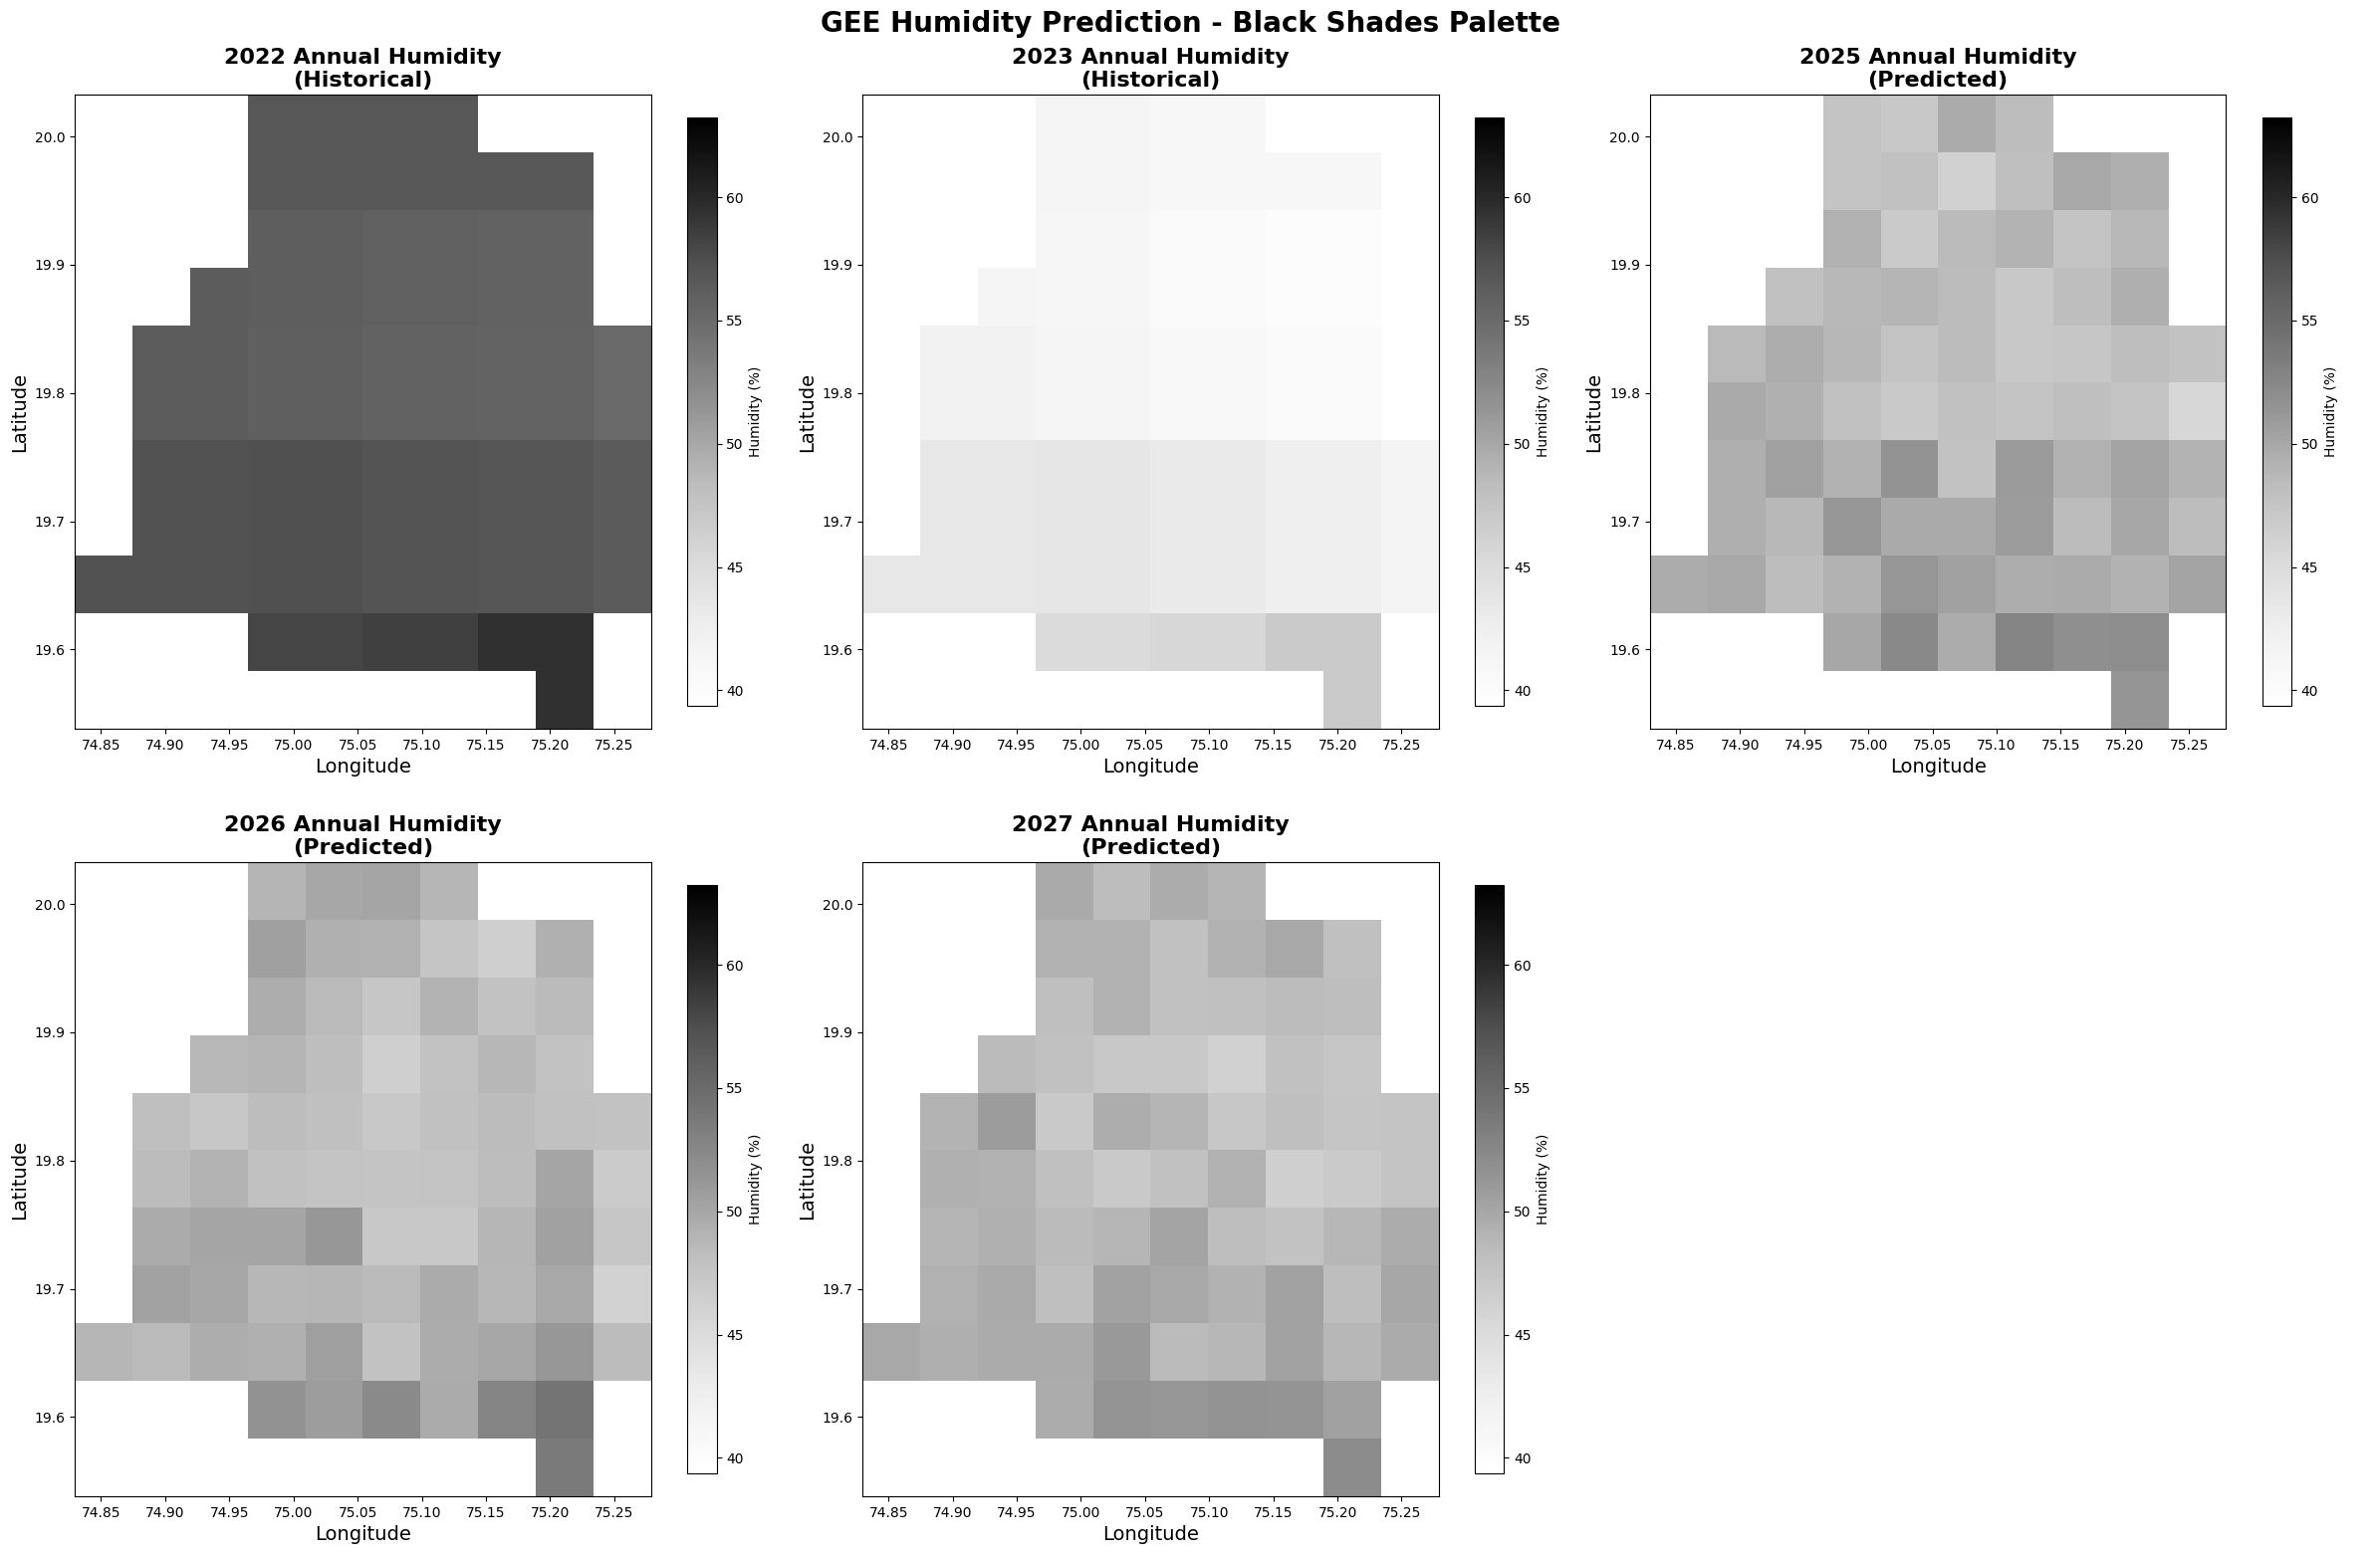

GEE Humidity Predictions for 2025-2027:
Historical:
2022: 56.7 %
2023: 42.1 %

Predicted (with climate change trend):
2025: 49.1 %
2026: 49.1 %
2027: 49.0 %

Data source: GEE Humidity folder
Climate change rate: -0.2% per year


In [28]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_and_predict_humidity_gee():
    # Use your GEE humidity TIFF folder
    humidity_tiff_folder = r"C:\Users\91772\Desktop\Gangapur\FINAL\GEE_Humidity"
    
    spatial_data = {}
    profile = None
    
    # Load humidity TIFF files
    for filename in os.listdir(humidity_tiff_folder):
        if filename.endswith('.tif'):
            try:
                # Extract year from filename - files are named like Gangapur_RH_1990.tif
                parts = filename.replace('.tif', '').split('_')
                year = None
                for part in parts:
                    if part.isdigit() and len(part) == 4:
                        year = int(part)
                        break
                
                if year is None:
                    continue
                    
                filepath = os.path.join(humidity_tiff_folder, filename)
                with rasterio.open(filepath) as src:
                    humidity_array = src.read(1)
                    if profile is None:
                        profile = src.profile
                        bounds = src.bounds
                    
                    spatial_data[year] = humidity_array
                    
            except:
                continue
    
    print(f"Loaded GEE humidity data for years: {sorted(spatial_data.keys())}")
    print(f"Humidity TIFF shape: {list(spatial_data.values())[0].shape}")
    print(f"Humidity bounds: {bounds}")
    
    # Calculate annual means
    annual_means = {}
    for year, humidity_data in spatial_data.items():
        annual_means[year] = np.nanmean(humidity_data)
    
    # Improved prediction with climate change trend
    years = sorted(spatial_data.keys())
    target_years = [2025, 2026, 2027]
    
    # Calculate historical trend
    X = np.array(years).reshape(-1, 1)
    y = [annual_means[year] for year in years]
    
    # Linear regression for trend
    lr_model = LinearRegression()
    lr_model.fit(X, y)
    
    # Add climate change effect (humidity typically decreases with warming)
    humidity_change_rate = -0.2  # % per year decrease
    base_year = years[-1]  # Last historical year
    base_humidity = annual_means[base_year]
    
    predicted_means = {}
    for year in target_years:
        years_ahead = year - base_year
        # Combine linear trend with climate change
        linear_pred = lr_model.predict([[year]])[0]
        climate_adjustment = base_humidity * (1 + (humidity_change_rate/100 * years_ahead))
        
        # Weighted average: 60% linear trend + 40% climate change
        predicted_means[year] = 0.6 * linear_pred + 0.4 * climate_adjustment
    
    # Create spatial predictions with variation
    height, width = list(spatial_data.values())[0].shape
    predicted_humidity = {}
    
    # Use recent spatial patterns
    historical_mean_spatial = np.nanmean([spatial_data[year] for year in years[-3:]], axis=0)
    
    for year in target_years:
        base_pred = predicted_means[year]
        
        # Add spatial variation based on historical patterns
        spatial_factor = historical_mean_spatial / np.nanmean(historical_mean_spatial)
        
        # Add small random variation for realism
        noise = np.random.normal(0, 0.02, (height, width))
        
        predicted_humidity[year] = base_pred * spatial_factor * (1 + noise)
        
        # Ensure reasonable humidity range (20-90%)
        predicted_humidity[year] = np.clip(predicted_humidity[year], 20, 90)
    
    return spatial_data, predicted_humidity, predicted_means, target_years, bounds

# Load and predict humidity from GEE folder
humidity_data, predicted_humidity, predicted_humidity_means, target_years, bounds = load_and_predict_humidity_gee()

# Set extent
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Visualize humidity with BLUE palette - 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# Get available historical years (last 2 years)
hist_years = sorted([y for y in humidity_data.keys() if y <= 2024])[-2:]

# Determine humidity range for consistent color scale
all_humidity = list(humidity_data.values()) + list(predicted_humidity.values())
humidity_min = min([np.nanmin(h) for h in all_humidity])
humidity_max = max([np.nanmax(h) for h in all_humidity])

# First row: Historical + 2025
im1 = axes[0,0].imshow(humidity_data[hist_years[0]], cmap='Greys', vmin=humidity_min, vmax=humidity_max, extent=extent)
axes[0,0].set_title(f'{hist_years[0]} Annual Humidity\n(Historical)', fontsize=16, fontweight='bold')
axes[0,0].set_xlabel('Longitude', fontsize=14)
axes[0,0].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im1, ax=axes[0,0], shrink=0.8, label='Humidity (%)')

im2 = axes[0,1].imshow(humidity_data[hist_years[1]], cmap='Greys', vmin=humidity_min, vmax=humidity_max, extent=extent)
axes[0,1].set_title(f'{hist_years[1]} Annual Humidity\n(Historical)', fontsize=16, fontweight='bold')
axes[0,1].set_xlabel('Longitude', fontsize=14)
axes[0,1].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im2, ax=axes[0,1], shrink=0.8, label='Humidity (%)')

im3 = axes[0,2].imshow(predicted_humidity[2025], cmap='Greys', vmin=humidity_min, vmax=humidity_max, extent=extent)
axes[0,2].set_title('2025 Annual Humidity\n(Predicted)', fontsize=16, fontweight='bold')
axes[0,2].set_xlabel('Longitude', fontsize=14)
axes[0,2].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im3, ax=axes[0,2], shrink=0.8, label='Humidity (%)')

# Second row: 2026, 2027, empty
im4 = axes[1,0].imshow(predicted_humidity[2026], cmap='Greys', vmin=humidity_min, vmax=humidity_max, extent=extent)
axes[1,0].set_title('2026 Annual Humidity\n(Predicted)', fontsize=16, fontweight='bold')
axes[1,0].set_xlabel('Longitude', fontsize=14)
axes[1,0].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im4, ax=axes[1,0], shrink=0.8, label='Humidity (%)')

im5 = axes[1,1].imshow(predicted_humidity[2027], cmap='Greys', vmin=humidity_min, vmax=humidity_max, extent=extent)
axes[1,1].set_title('2027 Annual Humidity\n(Predicted)', fontsize=16, fontweight='bold')
axes[1,1].set_xlabel('Longitude', fontsize=14)
axes[1,1].set_ylabel('Latitude', fontsize=14)
plt.colorbar(im5, ax=axes[1,1], shrink=0.8, label='Humidity (%)')

# Hide empty subplot
axes[1,2].axis('off')

plt.suptitle('GEE Humidity Prediction - Black Shades Palette', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Print humidity predictions
print("GEE Humidity Predictions for 2025-2027:")
print("="*60)
print("Historical:")
for year in hist_years:
    print(f"{year}: {np.nanmean(humidity_data[year]):.1f} %")
print("\nPredicted (with climate change trend):")
for year in target_years:
    print(f"{year}: {predicted_humidity_means[year]:.1f} %")
print(f"\nData source: GEE Humidity folder")
print("Climate change rate: -0.2% per year")